## Task 3 — extra insights

A few things beyond topic + sentiment that different teams would actually use.
This notebook **reads the scored dataset from notebook 2** (run notebooks 1 and 2
first) so all three share the same numbers. Gemini is only used here for the churn
reasons and the exec summary.

In [1]:
import pandas as pd
df = pd.read_csv("output/scored.csv")   # transcripts + topics + sentiment, from notebook 2
df.shape

(99, 16)

In [2]:
import os, enum
from google import genai
from google.genai import types
from pydantic import BaseModel

def load_env(path=".env"):
    """Read KEY=VALUE lines from a .env file into environment variables."""
    for line in open(path):
        line = line.strip()
        if line and not line.startswith("#") and "=" in line:
            k, v = line.split("=", 1)
            os.environ.setdefault(k.strip(), v.strip().strip("\"'"))
load_env()

MODEL = "gemini-3.1-flash-lite"
client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])

def ask(prompt, schema):
    """Send one prompt to Gemini and return the reply parsed into the given Pydantic schema."""
    resp = client.models.generate_content(
        model=MODEL, contents=prompt,
        config=types.GenerateContentConfig(
            response_mime_type="application/json",
            response_schema=schema,
            # small thinking budget: a little reasoning for ambiguous calls without
            # eating much of the token budget (0 = off, -1 = dynamic/unbounded)
            thinking_config=types.ThinkingConfig(thinking_budget=512),
            max_output_tokens=65536))
    return resp.parsed

def run_batch(items, schema, instruction):
    """Send all (id, text) items to Gemini in one call and return {id: parsed record}."""
    block = "\n\n".join(f"### ID: {cid}\n{txt}" for cid, txt in items)
    return {r.id: r for r in ask(f"{instruction}\nItems:\n{block}", list[schema])}

### 1. Does support pain show up internally? (eng/PM)
If a topic is hot in support and also in internal calls, engineering is aware of
it. If it's hot in support but *not* internal, that's a blind spot.

In [3]:
piv = (df.groupby(["category", "call_type"]).size().unstack(fill_value=0)
         .reindex(columns=["support", "external", "internal"], fill_value=0))
piv["in_both"] = (piv.support > 0) & (piv.internal > 0)
piv.sort_values("support", ascending=False)

call_type,support,external,internal,in_both
category,,,,
Authentication & Access,7,0,4,True
API & Integrations,6,4,0,False
Reliability & Performance,6,4,14,True
Product Feedback & Roadmap,5,9,8,True
Billing & Pricing,4,0,2,True
Data & Reporting,3,6,0,False
Adoption & Enablement,2,4,5,True
Renewal & Commercial,0,6,0,False


### 2. Churn radar (sales/CS)
Rank external accounts by negative sentiment + risk phrases, then let Gemini say
why each one's at risk so CS has something to act on.

In [4]:
RISK = ["alternativ", "evaluating", "move on", "confidence", "churn", "cancel",
        "disappointed", "shook", "reconsider", "clock is ticking"]
ext = df[df.call_type == "external"].copy()
ext["risk"] = ext.apply(
    lambda r: round(sum(r.text.lower().count(w) for w in RISK) + max(0, -r.sentiment_score) * 5, 2),
    axis=1)
top = ext.sort_values("risk", ascending=False).head(6).copy()

class Churn(BaseModel):
    id: str
    reason: str

why = run_batch(list(zip(top.call_id, top.text)), Churn,
    "For each account call, say in <=15 words why the customer might churn, or "
    "'no clear risk'. Keep the ID.")
top["churn_reason"] = [why[c].reason for c in top.call_id]
top[["call_id", "date", "topic", "sentiment_score", "risk", "churn_reason"]]

,call_id,date,topic,sentiment_score,risk,churn_reason
17,EXT-018,2026-03-20,Churn Risk & Escalation,-0.8,7.0,Previous outages caused significant loss of co...
16,EXT-017,2026-04-23,Churn Risk & Escalation,-0.7,6.5,"Previous outages caused loss of confidence, th..."
29,EXT-030,2026-03-23,Churn Risk & Escalation,-0.6,6.0,Previous outages caused mixed satisfaction and...
13,EXT-014,2026-04-27,Churn Risk & Escalation,-0.7,5.5,"Customer demands immediate, proven results aft..."
3,EXT-004,2026-03-14,Churn Risk & Escalation,-0.6,4.0,Customer explicitly threatened to leave if spe...
32,EXT-033,2026-05-04,Adoption & Onboarding,-0.2,1.0,"Slow internal adoption is a concern, though cu..."


### 3. Where to invest (product)
High volume + low sentiment = the topics worth fixing first. Something common but
fine (how-to) or rare but ugly (a one-off outage) matters less than something
that's both.

In [5]:
hot = (df.groupby("category").agg(
          volume=("call_id", "count"),
          sentiment=("sentiment_score", "mean"),
          pct_neg=("sentiment", lambda s: round((s == "negative").mean() * 100, 1)))
         .reset_index())
hot["sentiment"] = hot.sentiment.round(3)
hot["score"] = ((hot.volume / hot.volume.max()) * (1 - hot.sentiment)).round(3)
hot = hot.sort_values("score", ascending=False)
hot

,category,volume,sentiment,pct_neg,score
6,Reliability & Performance,24,-0.479,87.5,1.479
5,Product Feedback & Roadmap,22,0.105,18.2,0.820
2,Authentication & Access,11,-0.100,27.3,0.504
0,API & Integrations,10,-0.130,30.0,0.471
1,Adoption & Enablement,11,0.127,0.0,0.400
3,Billing & Pricing,6,-0.467,100.0,0.367
7,Renewal & Commercial,6,0.100,0.0,0.225
4,Data & Reporting,9,0.489,0.0,0.192


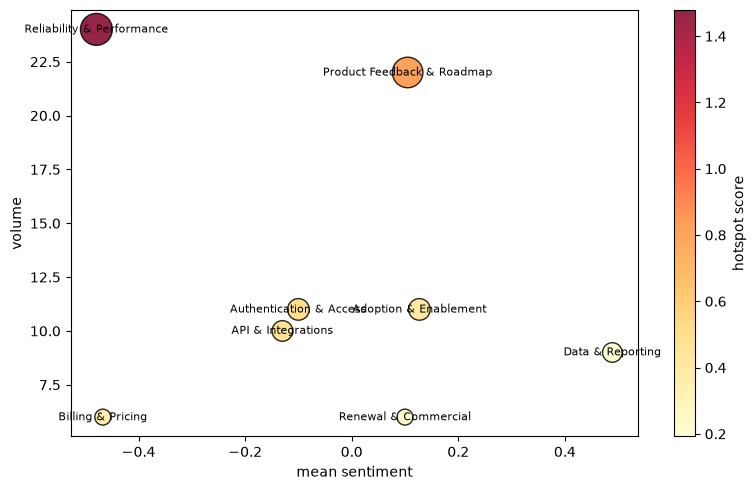

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(hot.sentiment, hot.volume, s=hot.volume * 22, c=hot.score,
                cmap="YlOrRd", edgecolor="k", alpha=0.85)
for _, r in hot.iterrows():
    ax.annotate(r.category, (r.sentiment, r.volume), fontsize=8, ha="center", va="center")
ax.set_xlabel("mean sentiment"); ax.set_ylabel("volume"); plt.colorbar(sc, label="hotspot score")
plt.tight_layout()

### 4. Rep coaching (idea, not built)
`delta` is the start→end sentiment swing per call. Averaged per rep (and adjusted
for how hard the calls were) it's a decent "who turns calls around" metric. I
didn't build it out because the synthetic data doesn't have real rep IDs, but the
column's already here.

In [7]:
df.groupby("call_type").delta.mean().round(3)

call_type
external    0.658
internal    0.379
support     0.445
Name: delta, dtype: float64

### 5. Exec summary
Hand the aggregates to Gemini for a short leadership readout.

In [8]:
import json

class Summary(BaseModel):
    summary: str

stats = {
    "n": int(len(df)),
    "by_type": {k: int(v) for k, v in df.call_type.value_counts().items()},
    "sentiment_by_type": df.groupby("call_type").sentiment_score.mean().round(3).to_dict(),
    "hotspots": hot.head(3)[["category", "volume", "sentiment"]].to_dict("records"),
    "churn": top.head(3)[["call_id", "topic", "risk"]].to_dict("records"),
}
prompt = ("Write a 4-5 sentence exec summary for product/eng leadership with one clear "
          "recommendation, using only these numbers.\n" + json.dumps(stats))
print(ask(prompt, Summary).summary)

An analysis of 99 customer interactions reveals distinct sentiment challenges across external (0.058), internal (-0.13), and support (-0.17) channels, each representing 33 occurrences. The most critical issue is identified within the 'Reliability & Performance' category, which accounts for 24 incidents with a significant negative sentiment of -0.479, alongside high-risk churn signals reaching scores up to 7.0. Given that Authentication & Access issues (11 volume, -0.1 sentiment) are also suppressing user satisfaction, immediate engineering bandwidth should be prioritized to stabilize core system reliability. We recommend allocating resources to address these performance hotspots to mitigate the current churn risks and improve overall sentiment across support and internal feedback loops.
